In [ ]:
!pip install -q emoji contractions wordfreq matplotlib seaborn openpyxl

In [ ]:
import os

ROOT_DIR = "/content/drive/My Drive/FDL_project"

EN_PATH = os.path.join(ROOT_DIR, "depression_dataset_reddit_cleaned.csv")
BN_PATH = os.path.join(ROOT_DIR, "BSMDD_v3_textcleaned - 21K.xlsx")

print("English dataset:", EN_PATH)
print("Bangla dataset:", BN_PATH)


English dataset: /content/drive/My Drive/FDL_project/depression_dataset_reddit_cleaned.csv
Bangla dataset: /content/drive/My Drive/FDL_project/BSMDD_v3_textcleaned - 21K.xlsx


In [ ]:
!pip install -q contractions wordfreq matplotlib seaborn openpyxl


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, unicodedata

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,5)


In [ ]:
# Load datasets
en_df = pd.read_csv(EN_PATH)
bn_df = pd.read_excel(BN_PATH)

print("English dataset shape:", en_df.shape)
print("Bangla dataset shape:", bn_df.shape)

display(en_df.head())
display(bn_df.head())


English dataset shape: (7731, 2)
Bangla dataset shape: (21910, 2)


,clean_text,is_depression
0,we understand that most people who reply immed...,1
1,welcome to r depression s check in post a plac...,1
2,anyone else instead of sleeping more when depr...,1
3,i ve kind of stuffed around a lot in my life d...,1
4,sleep is my greatest and most comforting escap...,1


,text,label
0,মানসিক শারীরিকভাবে অসুস্থ ক্লান্ত পুরো জীবন শা...,1
1,দয়া সাথে থাকুন অত্যন্ত দীর্ঘ আপনাকে পড়তে উত্...,1
2,জানতাম সাথে ভুল লোক খারাপ জীবন কাটিয়েছে সম্পূ...,1
3,অনেটিভ ইংরেজি স্পিকারের অনুসরণ বিরক্তিকর অপ্রত...,1
4,অনেটিভ ইংরেজি স্পিকারের অনুসরণ বিরক্তিকর অপ্রত...,1


In [ ]:
def detect_cols(df):
    text_candidates = ["text", "post", "content", "body", "message"]
    label_candidates = ["label", "class", "target", "sentiment"]

    cols = df.columns

    text_col = None
    label_col = None

    for t in text_candidates:
        for c in cols:
            if t.lower() in c.lower():
                text_col = c
                break

    for t in label_candidates:
        for c in cols:
            if t.lower() in c.lower():
                label_col = c
                break

    # fallback
    if text_col is None:
        text_col = cols[0]

    if label_col is None:
        for c in cols:
            if df[c].dropna().astype(str).isin(["0","1"]).any():
                label_col = c
                break

    return text_col, label_col


en_text, en_label = detect_cols(en_df)
bn_text, bn_label = detect_cols(bn_df)

print("English text:", en_text, "label:", en_label)
print("Bangla text:", bn_text, "label:", bn_label)

# Rename
en_df = en_df.rename(columns={en_text: "text", en_label: "label"})
bn_df = bn_df.rename(columns={bn_text: "text", bn_label: "label"})


English text: clean_text label: is_depression
Bangla text: text label: label


In [ ]:
# ============ English Cleaning (emoji-free, minimal) ============

import contractions

URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
HTML_PATTERN = re.compile(r"<.*?>")
MENTION_HASHTAG = re.compile(r"[@#]\w+")
MULTIPLE_SPACES = re.compile(r"\s+")
NON_PRINTABLE = re.compile(r"[\x00-\x1f\x7f-\x9f]")
REPEAT_CHAR = re.compile(r"(.)\1{2,}")

def clean_english(text):
    if pd.isna(text):
        return ""
    t = str(text)
    t = unicodedata.normalize("NFKC", t)
    t = t.lower()
    t = contractions.fix(t)
    t = URL_PATTERN.sub(" ", t)
    t = HTML_PATTERN.sub(" ", t)
    t = MENTION_HASHTAG.sub(" ", t)
    t = NON_PRINTABLE.sub(" ", t)
    t = REPEAT_CHAR.sub(r"\1\1", t)
    t = re.sub(r"[^a-z0-9\s\.\,\?\!']", " ", t)
    t = MULTIPLE_SPACES.sub(" ", t).strip()
    return t


# ============ Bangla Cleaning (emoji-free, minimal) ============

def clean_bangla(text):
    if pd.isna(text):
        return ""
    t = str(text)
    t = unicodedata.normalize("NFKC", t)
    t = URL_PATTERN.sub(" ", t)
    t = HTML_PATTERN.sub(" ", t)
    t = MENTION_HASHTAG.sub(" ", t)
    t = NON_PRINTABLE.sub(" ", t)
    t = re.sub(r"[A-Za-z]", " ", t)
    t = re.sub(r"[^\u0980-\u09FF0-9\s]", " ", t)
    t = MULTIPLE_SPACES.sub(" ", t).strip()
    return t


In [ ]:
print("Cleaning English...")
en_df["cleaned_text"] = en_df["text"].apply(clean_english)
en_df["lang"] = "en"

print("Cleaning Bangla...")
bn_df["cleaned_text"] = bn_df["text"].apply(clean_bangla)
bn_df["lang"] = "bn"


Cleaning English...
Cleaning Bangla...


In [ ]:
merged = pd.concat([en_df, bn_df], ignore_index=True)
merged["label"] = merged["label"].astype(int)
merged = merged[["text", "cleaned_text", "label", "lang"]]

SAVE_PATH = os.path.join(ROOT_DIR, "merged_bilingual_dataset.csv")
merged.to_csv(SAVE_PATH, index=False)

print("Merged dataset saved to:", SAVE_PATH)
print("Total rows:", len(merged))

display(merged.head())


Merged dataset saved to: /content/drive/My Drive/FDL_project/merged_bilingual_dataset.csv
Total rows: 29641


,text,cleaned_text,label,lang
0,we understand that most people who reply immed...,we understand that most people who reply immed...,1,en
1,welcome to r depression s check in post a plac...,welcome to r depression s check in post a plac...,1,en
2,anyone else instead of sleeping more when depr...,anyone else instead of sleeping more when depr...,1,en
3,i ve kind of stuffed around a lot in my life d...,i ve kind of stuffed around a lot in my life d...,1,en
4,sleep is my greatest and most comforting escap...,sleep is my greatest and most comforting escap...,1,en


Label distribution:


,count
label,
0,14849
1,14792



Label distribution per language:


lang  label
bn    0        10949
      1        10961
en    0         3900
      1         3831
dtype: int64

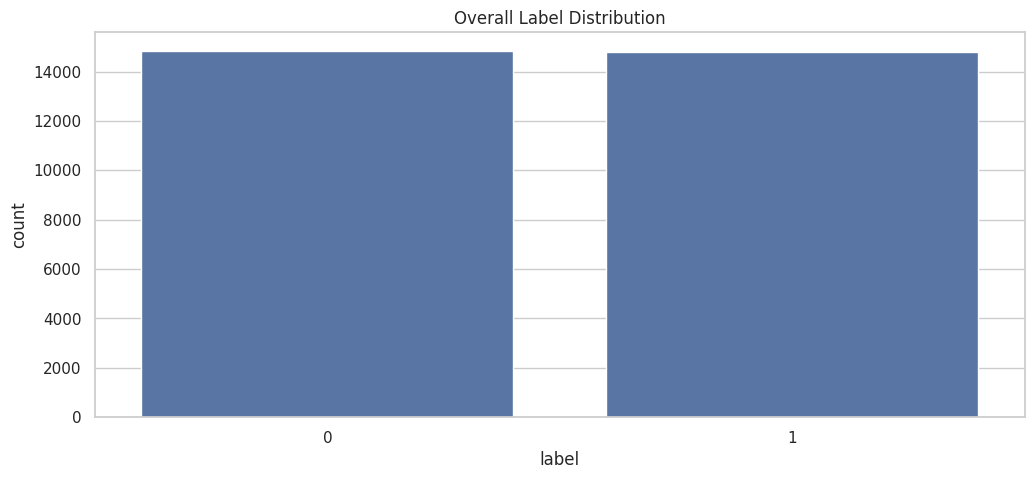

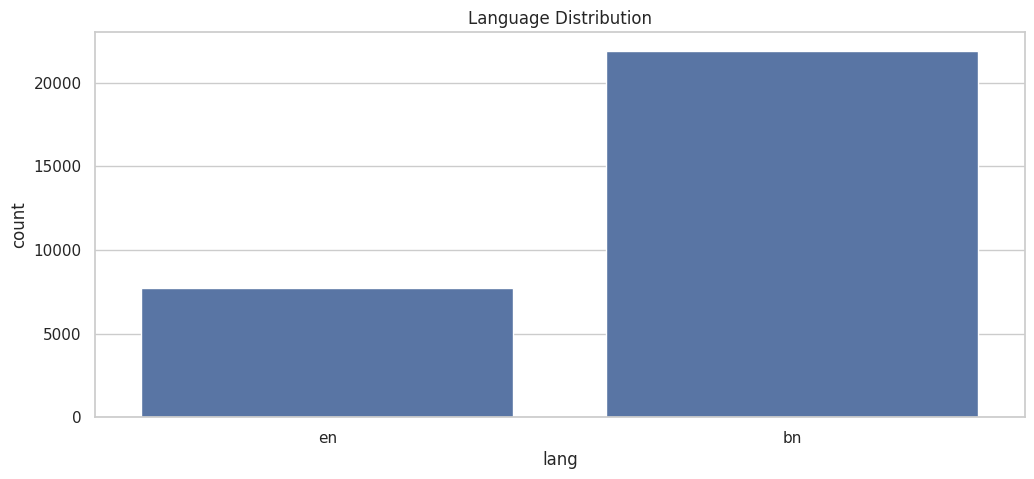

In [ ]:
print("Label distribution:")
display(merged["label"].value_counts())

print("\nLabel distribution per language:")
display(merged.groupby(["lang","label"]).size())

sns.countplot(data=merged, x="label")
plt.title("Overall Label Distribution")
plt.show()

sns.countplot(data=merged, x="lang")
plt.title("Language Distribution")
plt.show()


count    29641.000000
mean        79.034513
std         90.457916
min          0.000000
25%         29.000000
50%         53.000000
75%        101.000000
max       4245.000000
Name: token_len, dtype: float64
count    29641.000000
mean       501.849904
std        514.834474
min          0.000000
25%        186.000000
50%        352.000000
75%        674.000000
max      19797.000000
Name: char_len, dtype: float64


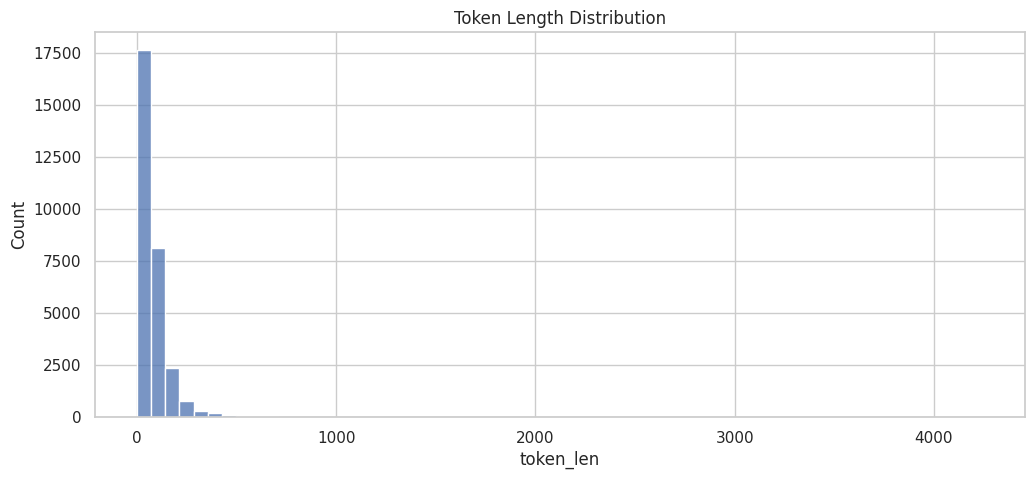

In [ ]:
merged["token_len"] = merged["cleaned_text"].apply(lambda x: len(str(x).split()))
merged["char_len"] = merged["cleaned_text"].apply(len)

print(merged["token_len"].describe())
print(merged["char_len"].describe())

sns.histplot(merged["token_len"], bins=60)
plt.title("Token Length Distribution")
plt.show()


In [ ]:
print("English Depressed examples:")
display(merged[(merged.lang=="en") & (merged.label==1)].sample(3))

print("Bangla Depressed examples:")
display(merged[(merged.lang=="bn") & (merged.label==1)].sample(3))


English Depressed examples:


,text,cleaned_text,label,lang,token_len,char_len
3235,lordreginald same but if they survived the gre...,lordreginald same but if they survived the gre...,1,en,14,85
2606,i just need to get everything in order i guess...,i just need to get everything in order i guess...,1,en,89,388
657,i ve been in therapy a few month cbt he mostly...,i ve been in therapy a few month cbt he mostly...,1,en,134,619


Bangla Depressed examples:


,text,cleaned_text,label,lang,token_len,char_len
10543,গুরুত্বপূর্ণ গুরুত্বপূর্ণ দৃঢ়ভাবে অনুভব করছি ...,গুরুত্বপূর্ণ গুরুত্বপূর্ণ দৃঢ়ভাবে অনুভব করছি ...,1,bn,135,951
27107,জীবন সবকিছুকে ঘৃণা মৃত্যুর কথা চিন্তা সময় আত্...,জীবন সবকিছুকে ঘৃণা মৃত্যুর কথা চিন্তা সময় আত্...,1,bn,29,190
11121,বাড়ির লোকের সাথে কঠিন তবুও বিশ্বাসে নিশ্চিত জ...,বাড়ির লোকের সাথে কঠিন তবুও বিশ্বাসে নিশ্চিত জ...,1,bn,120,883


In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
import os


In [ ]:
ROOT_DIR = "/content/drive/My Drive/FDL_project"
MERGED_PATH = os.path.join(ROOT_DIR, "merged_bilingual_dataset.csv")

df = pd.read_csv(MERGED_PATH)
print("Loaded:", MERGED_PATH)
print(df.shape)
df.head()


Loaded: /content/drive/My Drive/FDL_project/merged_bilingual_dataset.csv
(29641, 4)


,text,cleaned_text,label,lang
0,we understand that most people who reply immed...,we understand that most people who reply immed...,1,en
1,welcome to r depression s check in post a plac...,welcome to r depression s check in post a plac...,1,en
2,anyone else instead of sleeping more when depr...,anyone else instead of sleeping more when depr...,1,en
3,i ve kind of stuffed around a lot in my life d...,i ve kind of stuffed around a lot in my life d...,1,en
4,sleep is my greatest and most comforting escap...,sleep is my greatest and most comforting escap...,1,en


In [ ]:
df["stratify"] = df["label"].astype(str) + "_" + df["lang"].astype(str)
df["stratify"].value_counts()


,count
stratify,
1_bn,10961
0_bn,10949
0_en,3900
1_en,3831


In [ ]:
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)

for train_idx, temp_idx in splitter.split(df, df["stratify"]):
    train_df = df.iloc[train_idx]
    temp_df = df.iloc[temp_idx]

print("Train size:", train_df.shape)
print("Temp size:", temp_df.shape)


Train size: (23712, 5)
Temp size: (5929, 5)


In [ ]:
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)

for val_idx, test_idx in splitter.split(temp_df, temp_df["stratify"]):
    val_df = temp_df.iloc[val_idx]
    test_df = temp_df.iloc[test_idx]

print("Val size:", val_df.shape)
print("Test size:", test_df.shape)


Val size: (2964, 5)
Test size: (2965, 5)


In [ ]:
train_df = train_df.drop(columns=["stratify"])
val_df = val_df.drop(columns=["stratify"])
test_df = test_df.drop(columns=["stratify"])

train_path = os.path.join(ROOT_DIR, "train.csv")
val_path = os.path.join(ROOT_DIR, "val.csv")
test_path = os.path.join(ROOT_DIR, "test.csv")

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print("Saved:")
print("train →", train_path)
print("val   →", val_path)
print("test  →", test_path)


Saved:
train → /content/drive/My Drive/FDL_project/train.csv
val   → /content/drive/My Drive/FDL_project/val.csv
test  → /content/drive/My Drive/FDL_project/test.csv


In [ ]:
def show_distribution(df, name):
    print("\n===== ", name, " =====")
    print("Total:", len(df))
    print("\nLabel distribution:")
    print(df["label"].value_counts())
    print("\nLanguage distribution:")
    print(df["lang"].value_counts())
    print("\nLabel x Language distribution:")
    print(df.groupby(["lang","label"]).size())

show_distribution(train_df, "TRAIN")
show_distribution(val_df, "VALIDATION")
show_distribution(test_df, "TEST")



=====  TRAIN  =====
Total: 23712

Label distribution:
label
0    11879
1    11833
Name: count, dtype: int64

Language distribution:
lang
bn    17527
en     6185
Name: count, dtype: int64

Label x Language distribution:
lang  label
bn    0        8759
      1        8768
en    0        3120
      1        3065
dtype: int64

=====  VALIDATION  =====
Total: 2964

Label distribution:
label
0    1485
1    1479
Name: count, dtype: int64

Language distribution:
lang
bn    2191
en     773
Name: count, dtype: int64

Label x Language distribution:
lang  label
bn    0        1095
      1        1096
en    0         390
      1         383
dtype: int64

=====  TEST  =====
Total: 2965

Label distribution:
label
0    1485
1    1480
Name: count, dtype: int64

Language distribution:
lang
bn    2192
en     773
Name: count, dtype: int64

Label x Language distribution:
lang  label
bn    0        1095
      1        1097
en    0         390
      1         383
dtype: int64


In [ ]:
!pip install -q transformers datasets


In [ ]:
# CELL: Imports & paths
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from pprint import pprint

import torch
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler, WeightedRandomSampler

from transformers import AutoTokenizer, DataCollatorWithPadding
from tqdm.auto import tqdm

# Set paths
ROOT = "/content/drive/My Drive/FDL_project"
TRAIN_CSV = os.path.join(ROOT, "train.csv")
VAL_CSV   = os.path.join(ROOT, "val.csv")
TEST_CSV  = os.path.join(ROOT, "test.csv")

print("Files:")
print(TRAIN_CSV)
print(VAL_CSV)
print(TEST_CSV)

# reproducibility
RND = 42
random.seed(RND)
np.random.seed(RND)
torch.manual_seed(RND)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RND)


Files:
/content/drive/My Drive/FDL_project/train.csv
/content/drive/My Drive/FDL_project/val.csv
/content/drive/My Drive/FDL_project/test.csv


In [ ]:
# CELL: Hyperparameters & tokenizer init
MODEL_NAME = "xlm-roberta-base"   # change to a larger model if you have memory and compute
MAX_LEN = 256                     # recommended based on EDA
BATCH_SIZE = 16                   # adjust depending on GPU (use 8/16/32)
NUM_WORKERS = 2                   # DataLoader workers (0 on some colab runtimes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

# Example check: tokenizer behavior
print("Tokenizer vocab size:", tokenizer.vocab_size if hasattr(tokenizer, "vocab_size") else len(tokenizer))
print("Sample tokenization:", tokenizer("i am sad", return_tensors=None))


Device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizer vocab size: 250002
Sample tokenization: {'input_ids': [0, 17, 444, 17110, 2], 'attention_mask': [1, 1, 1, 1, 1]}


In [ ]:
# CELL: Custom Dataset
class BilingualTextDataset(Dataset):
    """
    Expects a DataFrame with columns:
      - 'cleaned_text'  (the preprocessed text we will tokenize)
      - 'label'         (0 or 1 integer)
      - 'lang'          (optional, 'en' or 'bn')
      - 'text'          (optional raw text)
    """
    def __init__(self, df: pd.DataFrame, tokenizer, max_len=256):
        self.df = df.reset_index(drop=True).copy()
        self.tokenizer = tokenizer
        self.max_len = max_len

        # simple sanity: cast label to int
        self.df['label'] = self.df['label'].astype(int)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row['cleaned_text'])  # use cleaned_text
        label = int(row['label'])
        lang = row.get("lang", None)
        raw = row.get("text", None)

        # We'll do tokenization in collate (for dynamic padding),
        # but we can also pre-tokenize here if preferred.
        return {
            "text": text,
            "label": label,
            "lang": lang,
            "raw_text": raw
        }


In [ ]:
# CELL: Data collator and tokenization helper (tokenize inside collate)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding="longest", return_tensors="pt")

def collate_fn(batch):
    """
    batch: list of dicts returned by Dataset.__getitem__
    We will tokenize the texts in the batch with truncation to MAX_LEN,
    and then use the HF data_collator to create padded tensors.
    """
    texts = [b["text"] for b in batch]
    labels = torch.tensor([b["label"] for b in batch], dtype=torch.long)
    langs  = [b["lang"] for b in batch]
    raw    = [b["raw_text"] for b in batch]

    # Tokenize (truncation to max length)
    enc = tokenizer(
        texts,
        truncation=True,
        max_length=MAX_LEN,
        return_attention_mask=True,
        return_token_type_ids=False,   # XLM-R does not use token_type_ids
    )

    # data_collator will convert lists->padded tensors
    batch_enc = data_collator(enc)

    # Attach labels and meta
    batch_enc["labels"] = labels
    batch_enc["langs"]  = langs
    batch_enc["raw_texts"] = raw

    return batch_enc


In [ ]:
# CELL: Create Datasets and DataLoaders
# Load csvs
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train/Val/Test shapes:", train_df.shape, val_df.shape, test_df.shape)

train_dataset = BilingualTextDataset(train_df, tokenizer, max_len=MAX_LEN)
val_dataset   = BilingualTextDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset  = BilingualTextDataset(test_df, tokenizer, max_len=MAX_LEN)

# Option A: standard RandomSampler for training
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=RandomSampler(train_dataset),
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    sampler=SequentialSampler(val_dataset),
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    sampler=SequentialSampler(test_dataset),
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("DataLoaders ready.")


Train/Val/Test shapes: (23712, 4) (2964, 4) (2965, 4)
DataLoaders ready.


In [ ]:
# CELL: Quick sanity check — iterate one batch and show shapes + example tokens
batch = next(iter(train_loader))
print("Batch keys:", list(batch.keys()))
print("input_ids shape:", batch["input_ids"].shape)
print("attention_mask shape:", batch["attention_mask"].shape)
print("labels shape:", batch["labels"].shape)
print("langs (first 8):", batch["langs"][:8])

# Decode the first input to verify tokenization/truncation
first_ids = batch["input_ids"][0].tolist()
print("\nDecoded sample (truncated):")
print(tokenizer.decode(first_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)[:400])


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Batch keys: ['input_ids', 'attention_mask', 'labels', 'langs', 'raw_texts']
input_ids shape: torch.Size([16, 256])
attention_mask shape: torch.Size([16, 256])
labels shape: torch.Size([16])
langs (first 8): ['bn', 'en', 'bn', 'bn', 'bn', 'bn', 'en', 'bn']

Decoded sample (truncated):
বড় ভয় করবো সারাদিন কেঁদেছি ভেবে কিভাবে প্রাপ্তবয়স্ক হচ্ছি শীঘ্রই শৈশব ছেড়ে বড় চাই যৌবন ভয়ঙ্কর শোনাচ্ছে বিষয়ে ভয়ঙ্কর আতঙ্কের আক্রমণ ঈশ্বরের বলছি নিজেকে আগুনে পুড়িয়ে ফেলব আশা পৃথিবী এতটা ভয়ঙ্কর ভীতিকর সময় থাকত প্রাপ্তবয়স্ক পৃথিবীকে বদলাতে চাই নোংরা কীভাবে রান্নাঘরের মেঝেতে কাঁদতে থাকি কীভাবে বিপর্যয় ঘটাতে সম্পর্কে রেডিট পোস্ট পরামর্শ


In [ ]:
# Run this cell (requires transformers + torch already installed)
import os
import torch
import torch.nn as nn
from transformers import AutoModel, AutoConfig, AutoTokenizer
from pathlib import Path

# Paths
ROOT = "/content/drive/My Drive/FDL_project"
CHECKPOINT_DIR = os.path.join(ROOT, "xlmr_checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [ ]:
class XLMRForBinaryClassification(nn.Module):
    """
    XLM-R encoder + single-logit binary classification head.
    Outputs a single logit per sample. Use BCEWithLogitsLoss for training.
    """
    def __init__(self, model_name="xlm-roberta-base", dropout_prob=0.3):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.encoder = AutoModel.from_pretrained(model_name, config=self.config)
        hidden_size = self.config.hidden_size  # usually 768

        self.dropout = nn.Dropout(dropout_prob)
        self.classifier = nn.Linear(hidden_size, 1)  # 1 logit

        nn.init.xavier_uniform_(self.classifier.weight)
        if self.classifier.bias is not None:
            nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)

        last_hidden = outputs.last_hidden_state       # (B, T, H)
        cls_rep = last_hidden[:,0,:]                 # (B, H)

        x = self.dropout(cls_rep)
        logits = self.classifier(x)                  # (B, 1)

        logits = logits.squeeze(-1)                  # FIX: now (B,)

        out = {"logits": logits}

        if labels is not None:
            labels = labels.to(dtype=torch.float, device=logits.device)
            loss_fct = nn.BCEWithLogitsLoss()
            loss = loss_fct(logits, labels)          # shapes now match
            out["loss"] = loss

        return out


In [ ]:
MODEL_NAME = "xlm-roberta-base"
DROPOUT = 0.3

model = XLMRForBinaryClassification(model_name=MODEL_NAME, dropout_prob=DROPOUT)
model = model.to(device)

print("Model loaded. Parameters (millions):", sum(p.numel() for p in model.parameters())/1e6)
# Quick parameter check: encoder vs head
encoder_params = sum(p.numel() for n,p in model.named_parameters() if "encoder" in n)
head_params = sum(p.numel() for n,p in model.named_parameters() if "classifier" in n or "dropout" in n)
print(f"Encoder params: {encoder_params:,}, Head params: {head_params:,}")


Model loaded. Parameters (millions): 278.044417
Encoder params: 278,043,648, Head params: 769


In [ ]:
# This uses the batch format created by the DataCollatorWithPadding collate_fn earlier
# Ensure `train_loader` exists in the notebook state (created earlier).
batch = next(iter(train_loader))
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["labels"].to(device)          # long dtype, but model will cast to float when computing loss

model.eval()
with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

print("Logits shape:", outputs['logits'].shape)   # expected (batch_size,)
if 'loss' in outputs:
    print("Loss (sanity; computed with random batch):", outputs['loss'].item())

# Show probabilities (sigmoid) for first 8 samples
import torch.nn.functional as F
probs = torch.sigmoid(outputs['logits'])
print("Probabilities (first 8):", probs[:8].cpu().numpy())


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Logits shape: torch.Size([16])
Loss (sanity; computed with random batch): 0.6991249322891235
Probabilities (first 8): [0.5474659  0.5460541  0.54808205 0.5505143  0.5509775  0.5519086
 0.55272555 0.54986584]


In [ ]:
def save_checkpoint(model, tokenizer, epoch, step, path_dir=CHECKPOINT_DIR, name_prefix="xlmr_bin"):
    """
    Saves model.state_dict and tokenizer files to a folder: path_dir/{name_prefix}_epoch{epoch}_step{step}
    """
    save_dir = os.path.join(path_dir, f"{name_prefix}_epoch{epoch}_step{step}")
    os.makedirs(save_dir, exist_ok=True)
    # Save model state_dict (lighter)
    ckpt_path = os.path.join(save_dir, "pytorch_model.bin")
    torch.save(model.state_dict(), ckpt_path)
    # Save config separately
    cfg_path = os.path.join(save_dir, "config.json")
    model.config.to_json_file(cfg_path)
    # Save tokenizer files too (so the folder can be loaded as HF model later)
    tokenizer.save_pretrained(save_dir)
    print("Saved checkpoint to:", save_dir)
    return save_dir

def load_checkpoint(model_class, model_name_or_path, device=device):
    """
    Load state dict into a newly created model instance (model_class accepts model_name param).
    model_name_or_path: folder path that contains pytorch_model.bin and tokenizer files
    """
    # model_class is XLMRForBinaryClassification
    model = model_class(model_name=model_name_or_path)
    state_path = os.path.join(model_name_or_path, "pytorch_model.bin")
    state_dict = torch.load(state_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    print("Loaded model from:", model_name_or_path)
    return model


In [ ]:
!pip install -q transformers datasets scikit-learn

In [ ]:
import os
import time
import math
from tqdm.auto import tqdm
from collections import defaultdict, Counter

import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Configurable hyperparameters
EPOCHS = 4                    # set higher for real training (4-6 is common)
LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 200
GRAD_CLIP = 1.0
GRADIENT_ACCUMULATION_STEPS = 1   # increase if you want effective larger batch
ACCELERATE = False               # placeholder if you want to use accelerate later

PATIENCE = 3  # early stopping patience for validation F1

# Options for class imbalance experiments (set True when running those experiments)
USE_POS_WEIGHT = False     # if True, will set pos_weight for BCEWithLogitsLoss (computed from train_df)
USE_FOCAL_LOSS = False     # if True, will use FocalLoss instead of BCEWithLogitsLoss
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.25

# Checkpoint folder
CHECKPOINT_DIR = "/content/drive/My Drive/FDL_project/xlmr_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("device:", device)
print("Num train steps estimate:", "approx", end=" ")
try:
    steps_per_epoch = math.ceil(len(train_loader.dataset) / (BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS))
    print(steps_per_epoch * EPOCHS)
except Exception as e:
    print("train loader missing; run dataloader cells first")


device: cpu
Num train steps estimate: approx 5928


In [ ]:
# Compute pos_weight = N_neg / N_pos (PyTorch expects pos_weight as a single number tensor)
if USE_POS_WEIGHT:
    train_labels = train_df['label'].values
    counter = Counter(train_labels)
    n_pos = counter.get(1, 0)
    n_neg = counter.get(0, 0)
    if n_pos == 0:
        raise ValueError("No positive examples in train set.")
    pos_weight_value = n_neg / n_pos
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float).to(device)
    print("pos_weight:", pos_weight_value)
else:
    pos_weight = None


In [ ]:
# Optional focal loss for binary tasks (works with logits input)
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        if alpha is not None:
            if isinstance(alpha, (float, int)):
                self.alpha = torch.tensor([alpha], dtype=torch.float)
            else:
                self.alpha = torch.tensor(alpha, dtype=torch.float)
        else:
            self.alpha = None
        self.reduction = reduction

    def forward(self, inputs, targets):
        """
        inputs: logits (B,)  (not probabilities)
        targets: binary labels (B,) float
        """
        # sigmoid to get probabilities
        prob = torch.sigmoid(inputs)
        prob = prob.clamp(min=1e-8, max=1.0-1e-8)

        # compute BCE loss per element
        bce_loss = -(targets * torch.log(prob) + (1 - targets) * torch.log(1 - prob))

        # p_t: prob for true class
        p_t = prob * targets + (1 - prob) * (1 - targets)
        loss = bce_loss * ((1 - p_t) ** self.gamma)

        if self.alpha is not None:
            # alpha weighting: alpha for positive class
            alpha_factor = self.alpha.to(inputs.device) * targets + (1 - self.alpha.to(inputs.device)) * (1 - targets)
            loss = alpha_factor * loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss


In [ ]:
# Optimizer params: typical weight decay setup
no_decay = ["bias", "LayerNorm.weight"]
optimizer_grouped_parameters = [
    {
        "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        "weight_decay": WEIGHT_DECAY,
    },
    {
        "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        "weight_decay": 0.0,
    },
]

optimizer = AdamW(optimizer_grouped_parameters, lr=LR)

# Scheduler requires total training steps
total_steps = math.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=total_steps)

# Choose loss
if USE_FOCAL_LOSS:
    criterion = FocalLoss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA)
    print("Using FocalLoss")
else:
    if pos_weight is not None:
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        print("Using BCEWithLogitsLoss with pos_weight")
    else:
        criterion = nn.BCEWithLogitsLoss()
        print("Using BCEWithLogitsLoss (no pos_weight)")

# For mixed precision
scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None


Using BCEWithLogitsLoss (no pos_weight)


In [ ]:
def sigmoid_to_label(logits, threshold=0.5):
    probs = torch.sigmoid(torch.tensor(logits))
    return (probs >= threshold).astype(int)

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

# Compute per-language metrics from arrays/lists
def per_language_metrics(y_true, y_pred, langs):
    dfm = pd.DataFrame({"y_true": y_true, "y_pred": y_pred, "lang": langs})
    results = {}
    for lang in dfm["lang"].unique():
        sub = dfm[dfm["lang"] == lang]
        if len(sub) == 0:
            continue
        res = compute_metrics(sub["y_true"].tolist(), sub["y_pred"].tolist())
        results[lang] = res
    return results


In [ ]:
best_val_f1 = -1.0
epochs_no_improve = 0
global_step = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    tk0 = tqdm(train_loader, desc=f"Epoch {epoch} Train", leave=True)
    optimizer.zero_grad()

    for step, batch in enumerate(tk0):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device).float()  # shape (B,)

        with torch.cuda.amp.autocast(enabled=(scaler is not None)):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs["logits"]  # shape (B,)
            if USE_FOCAL_LOSS:
                loss = criterion(logits, labels)
            else:
                loss = criterion(logits, labels)

            loss = loss / GRADIENT_ACCUMULATION_STEPS

        # backward
        if scaler is not None:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
            # gradient clipping
            if scaler is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

        epoch_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS
        tk0.set_postfix({"loss": f"{epoch_loss/(step+1):.4f}"})

    # End of epoch: validation
    model.eval()
    val_logits = []
    val_labels = []
    val_langs = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device).float()

            with torch.cuda.amp.autocast(enabled=(scaler is not None)):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs["logits"].detach().cpu().numpy()

            val_logits.extend(logits.tolist())
            val_labels.extend(labels.cpu().numpy().tolist())
            val_langs.extend(batch["langs"])

    # Convert logits -> binary preds
    import numpy as np
    val_probs = 1.0 / (1.0 + np.exp(-np.array(val_logits)))
    val_preds = (val_probs >= 0.5).astype(int)

    # Compute overall metrics
    metrics = compute_metrics(val_labels, val_preds)
    per_lang = per_language_metrics(val_labels, val_preds, val_langs)

    print(f"\nEpoch {epoch} validation metrics: loss={epoch_loss/len(train_loader):.4f}  |  val_f1={metrics['f1']:.4f}  |  val_acc={metrics['accuracy']:.4f}")
    print("Per-language validation metrics:", per_lang)

    # Early stopping / checkpoint by best val F1
    current_val_f1 = metrics['f1']
    if current_val_f1 > best_val_f1:
        best_val_f1 = current_val_f1
        epochs_no_improve = 0
        # Save checkpoint
        ckpt_name = f"best_epoch{epoch}_f1{best_val_f1:.4f}"
        ckpt_path = os.path.join(CHECKPOINT_DIR, ckpt_name)
        os.makedirs(ckpt_path, exist_ok=True)
        # Save state_dict + tokenizer
        torch.save(model.state_dict(), os.path.join(ckpt_path, "pytorch_model.bin"))
        tokenizer.save_pretrained(ckpt_path)
        print("Saved new best model to:", ckpt_path)
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s). Best f1: {best_val_f1:.4f}")

    if epochs_no_improve >= PATIENCE:
        print("Early stopping triggered. Stopping training.")
        break

print("Training finished. Best val F1:", best_val_f1)


Epoch 1 Train:   0%|          | 0/1482 [00:00<?, ?it/s]

/tmp/ipython-input-1426775097.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):


Validation:   0%|          | 0/186 [00:00<?, ?it/s]

/tmp/ipython-input-1426775097.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):



Epoch 1 validation metrics: loss=0.3479  |  val_f1=0.9075  |  val_acc=0.9069
Per-language validation metrics: {'en': {'accuracy': 0.981888745148771, 'precision': 0.9767441860465116, 'recall': 0.9869451697127938, 'f1': 0.9818181818181818}, 'bn': {'accuracy': 0.8804198995892286, 'precision': 0.8729874776386404, 'recall': 0.8905109489051095, 'f1': 0.8816621499548328}}
Saved new best model to: /content/drive/My Drive/FDL_project/xlmr_checkpoints/best_epoch1_f10.9075


...

Epoch 4 Train:   0%|          | 0/1482 [00:00<?, ?it/s]

/tmp/ipython-input-1426775097.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):


Validation:   0%|          | 0/186 [00:00<?, ?it/s]

/tmp/ipython-input-1426775097.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):



Epoch 4 validation metrics: loss=0.1309  |  val_f1=0.9256  |  val_acc=0.9258
Per-language validation metrics: {'en': {'accuracy': 0.9883570504527813, 'precision': 0.9844559585492227, 'recall': 0.9921671018276762, 'f1': 0.988296488946684}, 'bn': {'accuracy': 0.9036969420356001, 'precision': 0.9055912007332723, 'recall': 0.9014598540145985, 'f1': 0.9035208047553727}}
Saved new best model to: /content/drive/My Drive/FDL_project/xlmr_checkpoints/best_epoch4_f10.9256
Training finished. Best val F1: 0.925575101488498


In [ ]:
# If you want to load the best saved checkpoint, uncomment and set path:
# best_ckpt_path = "/content/drive/My Drive/FDL_project/xlmr_checkpoints/best_epochX_f1YYY"
# model = load_checkpoint(XLMRForBinaryClassification, best_ckpt_path, device=device)
# model.to(device)
# model.eval()

test_logits = []
test_labels = []
test_langs = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device).float()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs["logits"].detach().cpu().numpy()

        test_logits.extend(logits.tolist())
        test_labels.extend(labels.cpu().numpy().tolist())
        test_langs.extend(batch["langs"])

import numpy as np
test_probs = 1.0 / (1.0 + np.exp(-np.array(test_logits)))
test_preds = (test_probs >= 0.5).astype(int)

test_metrics = compute_metrics(test_labels, test_preds)
test_per_lang = per_language_metrics(test_labels, test_preds, test_langs)

print("Test overall metrics:", test_metrics)
print("Test per-language metrics:", test_per_lang)


Testing:   0%|          | 0/186 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Load full train/val/test sets again (just to be safe)
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print(train_df['lang'].value_counts())
print(val_df['lang'].value_counts())
print(test_df['lang'].value_counts())

# English-only subsets
train_en = train_df[train_df.lang == "en"].reset_index(drop=True)
val_en   = val_df[val_df.lang == "en"].reset_index(drop=True)
test_en  = test_df[test_df.lang == "en"].reset_index(drop=True)

# Bangla-only subsets
train_bn = train_df[train_df.lang == "bn"].reset_index(drop=True)
val_bn   = val_df[val_df.lang == "bn"].reset_index(drop=True)
test_bn  = test_df[test_df.lang == "bn"].reset_index(drop=True)


In [ ]:
def make_loader(df, batch_size=BATCH_SIZE, shuffle=True):
    dataset = BilingualTextDataset(df, tokenizer, max_len=MAX_LEN)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collate_fn,
        num_workers=2,
        pin_memory=True,
    )
    return loader


In [ ]:
def train_subset(train_df_sub, val_df_sub, model_name_suffix):
    global model, optimizer, scheduler, scaler

    # Build loaders
    train_loader_sub = make_loader(train_df_sub, shuffle=True)
    val_loader_sub   = make_loader(val_df_sub, shuffle=False)

    print(f"Training on subset: {model_name_suffix}")
    print("Train size:", len(train_df_sub))
    print("Val size:", len(val_df_sub))

    # Re-initialize model for a fresh train
    model = XLMRForBinaryClassification(model_name="xlm-roberta-base").to(device)

    # Recreate optimizer & scheduler
    optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
    total_steps = len(train_loader_sub) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=200,
        num_training_steps=total_steps,
    )
    scaler = torch.cuda.amp.GradScaler()

    best_val_f1 = -1
    best_path = None

    # Main training loop
    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss = 0
        loop = tqdm(train_loader_sub, desc=f"[{model_name_suffix}] Epoch {epoch}")

        for batch in loop:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device).float()

            with torch.cuda.amp.autocast():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs["logits"]
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

            epoch_loss += loss.item()
            loop.set_postfix(loss=epoch_loss / (loop.n + 1))

        # Validation
        model.eval()
        val_logits, val_labels = [], []

        with torch.no_grad():
            for batch in val_loader_sub:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                out = model(input_ids=input_ids, attention_mask=attention_mask)
                val_logits.extend(out["logits"].cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        # Compute metrics
        val_probs = 1 / (1 + np.exp(-np.array(val_logits)))
        val_preds = (val_probs >= 0.5).astype(int)

        metrics = compute_metrics(val_labels, val_preds)

        print(f">>> {model_name_suffix} Epoch {epoch} — Val F1 = {metrics['f1']:.4f}")

        # Save best
        if metrics["f1"] > best_val_f1:
            best_val_f1 = metrics["f1"]
            best_path = os.path.join(
                CHECKPOINT_DIR,
                f"{model_name_suffix}_best_f1_{best_val_f1:.4f}"
            )
            os.makedirs(best_path, exist_ok=True)
            torch.save(model.state_dict(), os.path.join(best_path, "pytorch_model.bin"))
            tokenizer.save_pretrained(best_path)

    print(f"BEST model saved at: {best_path}")
    return best_path


In [ ]:
def test_subset(model_path, test_df_sub, test_name):
    print("\nEvaluating:", test_name)
    print("Test size:", len(test_df_sub))

    # Load model
    model = XLMRForBinaryClassification().to(device)
    model.load_state_dict(torch.load(os.path.join(model_path, "pytorch_model.bin"), map_location=device))
    model.eval()

    # Loader
    test_loader_sub = make_loader(test_df_sub, shuffle=False)

    test_logits, test_labels = [], []

    with torch.no_grad():
        for batch in tqdm(test_loader_sub):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].numpy()

            out = model(input_ids=input_ids, attention_mask=attention_mask)
            test_logits.extend(out["logits"].cpu().numpy())
            test_labels.extend(labels)

    test_probs = 1 / (1 + np.exp(-np.array(test_logits)))
    preds = (test_probs >= 0.5).astype(int)

    m = compute_metrics(test_labels, preds)
    print(f"{test_name} → Accuracy={m['accuracy']:.4f}, F1={m['f1']:.4f}, Precision={m['precision']:.4f}, Recall={m['recall']:.4f}")
    return m


In [ ]:
path_en = train_subset(train_en, val_en, "trainEN")
test_en_to_bn = test_subset(path_en, test_bn, "EN→BN")


In [ ]:
path_bn = train_subset(train_bn, val_bn, "trainBN")
test_bn_to_en = test_subset(path_bn, test_en, "BN→EN")


In [ ]:
bilingual_best_path = "/content/drive/My Drive/FDL_project/xlmr_checkpoints/best_epoch4_f10.9228"

test_bilingual_en  = test_subset(bilingual_best_path, test_en,  "BI→EN")
test_bilingual_bn  = test_subset(bilingual_best_path, test_bn,  "BI→BN")


In [ ]:
results = pd.DataFrame({
    "Model": ["EN→BN", "BN→EN", "BI→EN", "BI→BN"],
    "F1": [
        test_en_to_bn["f1"],
        test_bn_to_en["f1"],
        test_bilingual_en["f1"],
        test_bilingual_bn["f1"],
    ]
})

results


,Model,F1
0,EN→BN,0.660720
1,BN→EN,0.733104
2,BI→EN,0.973684
3,BI→BN,0.916590


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

def merge_wordpieces(tokens):
    merged = []
    for tok in tokens:
        tok = tok.replace("▁", " ")  # XLM-R uses ▁ to mark word-starts
        merged.append(tok)
    text = "".join(merged)
    return text.strip().split()

def attention_heatmap_clean(text, max_len=128):
    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_len).to(device)

    with torch.no_grad():
        out = model.encoder(
            input_ids=enc["input_ids"],
            attention_mask=enc["attention_mask"],
            output_attentions=True,
            return_dict=True
        )
        attn = out.attentions[-1].mean(1).squeeze(0)

    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"].squeeze())

    # merge subwords → real words
    merged_tokens = merge_wordpieces(tokens)

    # Resize attention to merge same-length vector
    cls_scores = attn[0].cpu().numpy()
    cls_scores = cls_scores[:len(merged_tokens)]  # align with merged tokens

    plt.figure(figsize=(12, 2.5))
    sns.heatmap([cls_scores], cmap="plasma", xticklabels=merged_tokens, yticklabels=["CLS→"])
    plt.xticks(rotation=45, ha='right')
    plt.title("Attention Heatmap (Merged Tokens)")
    plt.tight_layout()
    plt.show()


XLMRobertaSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


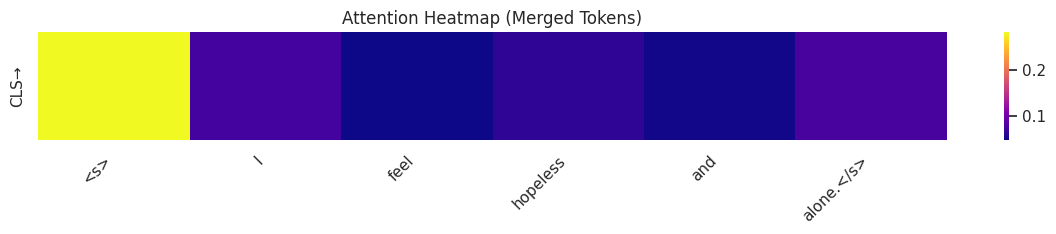

In [ ]:
attention_heatmap_clean("I feel hopeless and alone.")


In [ ]:
!apt-get update
!apt-get install -y fonts-noto fonts-noto-cjk fonts-noto-color-emoji

# Download Noto Sans Bengali Regular
!wget -O /usr/share/fonts/truetype/NotoSansBengali-Regular.ttf \
"https://github.com/googlefonts/noto-fonts/blob/main/hinted/ttf/NotoSansBengali/NotoSansBengali-Regular.ttf?raw=true"

# Refresh the font cache
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
print("Fonts installed!")


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [343 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,138 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InReleas

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Noto Sans Bengali'
plt.rcParams['axes.unicode_minus'] = False

print("Matplotlib now using Bengali font ✔")


Matplotlib now using Bengali font ✔


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 115 (s) missing from font(s) Noto Sans Bengali.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 67 (C) missing from font(s) Noto Sans Bengali.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 76 (L) missing from font(s) Noto Sans Bengali.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 83 (S) missing from font(s) Noto Sans Bengali.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing

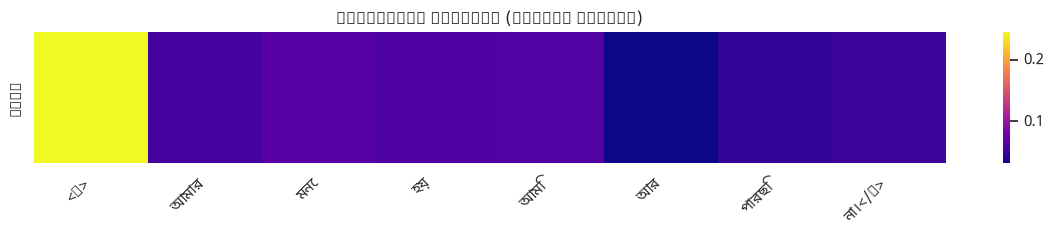

In [ ]:
attention_heatmap_clean("আমার মনে হয় আমি আর পারছি না।")


In [ ]:
def attention_heatmap_clean(text, max_len=128):
    encoding = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_len).to(device)

    with torch.no_grad():
        output = model.encoder(
            input_ids=encoding["input_ids"],
            attention_mask=encoding["attention_mask"],
            output_attentions=True,
            return_dict=True
        )
        attn = output.attentions[-1].mean(1).squeeze(0)

    tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"].squeeze())
    merged_tokens = merge_wordpieces(tokens)

    cls_scores = attn[0].cpu().numpy()[:len(merged_tokens)]

    fig, ax = plt.subplots(figsize=(12,3))
    sns.heatmap([cls_scores], cmap="viridis", xticklabels=merged_tokens, yticklabels=["CLS→"], ax=ax)

    # force tick font to Bengali
    for label in ax.get_xticklabels():
        label.set_fontproperties(fm.FontProperties(fname="/usr/share/fonts/truetype/NotoSansBengali-Regular.ttf"))
        label.set_rotation(45)
        label.set_horizontalalignment('right')

    plt.title("Attention Heatmap (Bangla Compatible)")
    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 115 (s) missing from font(s) Noto Sans Bengali.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 67 (C) missing from font(s) Noto Sans Bengali.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 76 (L) missing from font(s) Noto Sans Bengali.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 83 (S) missing from font(s) Noto Sans Bengali.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing

NameError: name 'fm' is not defined

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 115 (s) missing from font(s) Noto Sans Bengali.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 67 (C) missing from font(s) Noto Sans Bengali.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 76 (L) missing from font(s) Noto Sans Bengali.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 83 (S) missing from font(s) Noto Sans Bengali.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Noto Sans Bengali.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/l

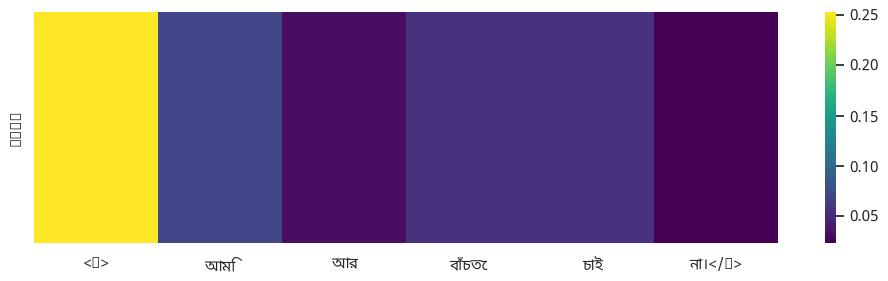

In [ ]:
attention_heatmap_clean("আমি আর বাঁচতে চাই না।")


In [ ]:
!apt-get update
!apt-get install -y fonts-noto-core fonts-noto-ui-core fonts-noto-unhinted
!wget -O /usr/share/fonts/truetype/NotoSansBengali-Regular.ttf \
https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansBengali/NotoSansBengali-Regular.ttf

import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

print("Bangla Font Installed ✔")


Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://cli.github.com/packages stable InRelease [3,917 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:11 https://cli.github.com/packages stable/main amd64 Packages [343 B]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages 

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Noto Sans Bengali'
plt.rcParams['text.usetex'] = False

print("Default Bengali font set ✔")


Default Bengali font set ✔


In [ ]:
def attention_heatmap_clean(text, max_len=128):
    encoding = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_len).to(device)

    with torch.no_grad():
        output = model.encoder(
            input_ids=encoding["input_ids"],
            attention_mask=encoding["attention_mask"],
            output_attentions=True,
            return_dict=True
        )
        attn = output.attentions[-1].mean(1).squeeze(0)

    tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"].squeeze())
    merged_tokens = merge_wordpieces(tokens)

    cls_scores = attn[0].cpu().numpy()[:len(merged_tokens)]

    fig, ax = plt.subplots(figsize=(12,3))
    sns.heatmap([cls_scores], cmap="viridis", xticklabels=merged_tokens, yticklabels=["CLS→"], ax=ax)

    # force tick font to Bengali
    for label in ax.get_xticklabels():
        label.set_fontproperties(fm.FontProperties(fname="/usr/share/fonts/truetype/NotoSansBengali-Regular.ttf"))
        label.set_rotation(45)
        label.set_horizontalalignment('right')

    plt.title("Attention Heatmap (Bangla Compatible)")
    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-p

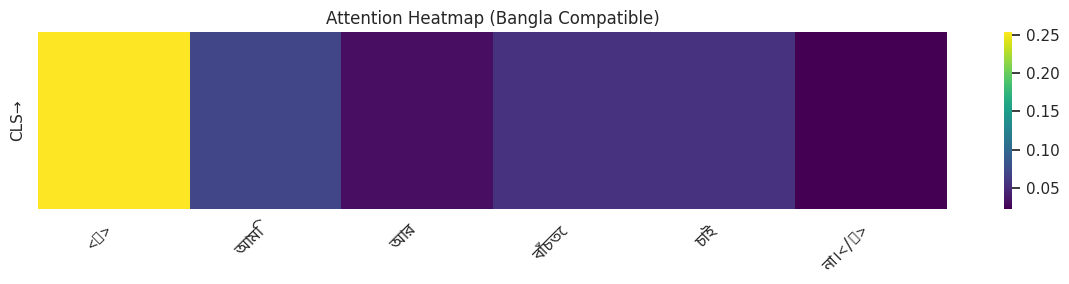

In [ ]:
attention_heatmap_clean("আমি আর বাঁচতে চাই না।")


In [ ]:
import os
from sklearn.metrics import confusion_matrix
import torch

device = torch.device("cpu")
model.to(device)  # ensure model is on CPU

# ensure output directory
SAVE_DIR = "/content/drive/My Drive/FDL_project/XAI_Final"
os.makedirs(f"{SAVE_DIR}/attention", exist_ok=True)
os.makedirs(f"{SAVE_DIR}/lime", exist_ok=True)

test_texts = test_df["text"].tolist()
test_langs = test_df["lang"].tolist()
test_labels = test_df["label"].tolist()

preds = []
probs = []

model.eval()
with torch.no_grad():
    for i, text in enumerate(test_texts):
        enc = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
        enc = {k: v.to(device) for k, v in enc.items()}

        outputs = model(enc["input_ids"], enc["attention_mask"])
        logit = outputs["logits"].squeeze()
        prob = torch.sigmoid(logit).item()

        preds.append(1 if prob >= 0.5 else 0)
        probs.append(prob)

# Update dataframe
test_df["pred"] = preds
test_df["prob"] = probs

print("Prediction ready ✔ (CPU)")




KeyboardInterrupt: 